In [1]:
import pandas as pd
import numpy as np

In [4]:
fact = pd.read_csv("cleaned_fact_water_samples.csv")
locations = pd.read_csv("dim_locations_cleaned.csv")
polymers = pd.read_csv("dim_polymers_cleaned.csv")
weather = pd.read_csv("microplastic_weather_dataset_with_dates.csv")

In [5]:
print("Fact:", fact.shape)
print("Locations:", locations.shape)
print("Polymers:", polymers.shape)
print("Weather:", weather.shape)

Fact: (1000, 12)
Locations: (10, 8)
Polymers: (6, 5)
Weather: (1627, 5)


In [6]:
fact["Location_ID"] = (
    fact["Location_ID"]
    .str.upper()
    .str.strip())
locations["Location_ID"] = (
    locations["Location_ID"]
    .str.upper()
    .str.strip())
weather["Location_ID"] = (
    weather["Location_ID"]
    .str.upper()
    .str.strip())

In [7]:
print(fact["Location_ID"].unique())
print(locations["Location_ID"].unique())

['LOC-107' 'LOC-104' 'LOC-108' 'LOC-105' 'LOC-110' 'LOC-103' 'LOC-106'
 'LOC-102' 'LOC-101' 'LOC-109']
['LOC-101' 'LOC-102' 'LOC-103' 'LOC-104' 'LOC-105' 'LOC-106' 'LOC-107'
 'LOC-108' 'LOC-109' 'LOC-110']


In [8]:
fact["Timestamp"] = pd.to_datetime(
    fact["Timestamp"]
)
weather["Date"] = pd.to_datetime(
    weather["Date"]
)

In [10]:
fact["Timestamp"] = pd.to_datetime(
    fact["Timestamp"]
)
weather["Date"] = pd.to_datetime(
    weather["Date"]
)

In [11]:
fact["Date"] = fact["Timestamp"].dt.date

In [12]:
combined = fact.merge(
    locations,
    on="Location_ID",
    how="left"
)

In [13]:
print(combined.shape)

(1000, 20)


In [14]:
combined = combined.merge(
    polymers,
    left_on="Dominant_Polymer",
    right_on="Polymer_Code",
    how="left"
)

In [15]:
weather["Year"] = weather["Date"].dt.year
weather["Month"] = weather["Date"].dt.month

In [16]:
weather_monthly = (weather
    .groupby(["Location_ID", "Month"],as_index=False)
    [["Rainfall_mm","Wind_Speed_kmh","Surface_Runoff_Index"]]
    .mean()
)

In [17]:
weather_monthly.rename(
    columns={"Rainfall_mm": "Avg_Rainfall_mm","Wind_Speed_kmh": "Avg_Wind_Speed_kmh","Surface_Runoff_Index": "Avg_Surface_Runoff_Index"},inplace=True)

In [18]:
combined["Month"] = (
    pd.to_datetime(
        combined["Timestamp"]
    ).dt.month
)

In [19]:
combined = combined.merge(
    weather_monthly,
    on=["Location_ID", "Month"],
    how="left"
)

In [20]:
print("Combined Dataset Shape:",combined.shape)

Combined Dataset Shape: (1000, 29)


In [21]:
combined.head()

,Sample_ID,Timestamp,Location_ID,Water_Temp_C,pH_Level,Turbidity_NTU,Dissolved_Oxygen_mgL,Microplastic_Count_per_m3,Dominant_Polymer,Dominant_Morphology,...,Nearby_Industry_Type,Polymer_Code,Polymer_Name,Common_Sources,Toxicity_Score,Degradation_Rate_Years,Month,Avg_Rainfall_mm,Avg_Wind_Speed_kmh,Avg_Surface_Runoff_Index
0,SMP-2026-0001,2026-01-01 00:00:00,LOC-107,9.2,7.38,33.32,10.62,552,PE,Fiber,...,Agriculture Runoff,PE,Polyethylene,"Plastic bags, bottles, packaging",3,450,1,2.301290,16.141935,1.044194
1,SMP-2026-0002,2026-01-01 04:00:00,LOC-104,8.6,8.37,23.87,11.34,422,PS,Foam,...,Municipal Sewage,PS,Polystyrene,"Foam cups, insulation, packaging",7,500,1,NaN,NaN,NaN
2,SMP-2026-0003,2026-01-01 08:00:00,LOC-108,22.3,7.35,1.95,7.77,39,PET,Film,...,Chemical Processing,PET,Polyethylene Terephthalate,"Beverage bottles, synthetic clothing",4,450,1,NaN,NaN,NaN
3,SMP-2026-0004,2026-01-01 12:00:00,LOC-105,15.2,7.76,39.15,8.69,529,PS,Fiber,...,Maritime & Shipping,PS,Polystyrene,"Foam cups, insulation, packaging",7,500,1,0.969032,17.987097,0.489032
4,SMP-2026-0005,2026-01-01 16:00:00,LOC-107,10.5,7.41,3.38,11.15,87,PS,Foam,...,Agriculture Runoff,PS,Polystyrene,"Foam cups, insulation, packaging",7,500,1,2.301290,16.141935,1.044194


In [22]:
combined.isnull().sum()

Sample_ID                      0
Timestamp                      0
Location_ID                    0
Water_Temp_C                   0
pH_Level                       0
Turbidity_NTU                  0
Dissolved_Oxygen_mgL           0
Microplastic_Count_per_m3      0
Dominant_Polymer               0
Dominant_Morphology            0
Average_Particle_Size_mm       0
Risk_Level                     0
Date                           0
Location_Name                  0
Water_Body_Type                0
Latitude                       0
Longitude                      0
City                           0
State                          0
Nearby_Industry_Type           0
Polymer_Code                   0
Polymer_Name                   0
Common_Sources                 0
Toxicity_Score                 0
Degradation_Rate_Years         0
Month                          0
Avg_Rainfall_mm              366
Avg_Wind_Speed_kmh           366
Avg_Surface_Runoff_Index     366
dtype: int64

In [23]:
combined.to_csv(
    "combined_ml_dataset.csv",
    index=False
)
print("Combined dataset created successfully!")

Combined dataset created successfully!


In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

In [29]:
#Model training
df = pd.read_csv(
    "combined_ml_dataset.csv"
)

print(df.shape)
df.head()

(1000, 29)


,Sample_ID,Timestamp,Location_ID,Water_Temp_C,pH_Level,Turbidity_NTU,Dissolved_Oxygen_mgL,Microplastic_Count_per_m3,Dominant_Polymer,Dominant_Morphology,...,Nearby_Industry_Type,Polymer_Code,Polymer_Name,Common_Sources,Toxicity_Score,Degradation_Rate_Years,Month,Avg_Rainfall_mm,Avg_Wind_Speed_kmh,Avg_Surface_Runoff_Index
0,SMP-2026-0001,2026-01-01 00:00:00,LOC-107,9.2,7.38,33.32,10.62,552,PE,Fiber,...,Agriculture Runoff,PE,Polyethylene,"Plastic bags, bottles, packaging",3,450,1,2.301290,16.141935,1.044194
1,SMP-2026-0002,2026-01-01 04:00:00,LOC-104,8.6,8.37,23.87,11.34,422,PS,Foam,...,Municipal Sewage,PS,Polystyrene,"Foam cups, insulation, packaging",7,500,1,NaN,NaN,NaN
2,SMP-2026-0003,2026-01-01 08:00:00,LOC-108,22.3,7.35,1.95,7.77,39,PET,Film,...,Chemical Processing,PET,Polyethylene Terephthalate,"Beverage bottles, synthetic clothing",4,450,1,NaN,NaN,NaN
3,SMP-2026-0004,2026-01-01 12:00:00,LOC-105,15.2,7.76,39.15,8.69,529,PS,Fiber,...,Maritime & Shipping,PS,Polystyrene,"Foam cups, insulation, packaging",7,500,1,0.969032,17.987097,0.489032
4,SMP-2026-0005,2026-01-01 16:00:00,LOC-107,10.5,7.41,3.38,11.15,87,PS,Foam,...,Agriculture Runoff,PS,Polystyrene,"Foam cups, insulation, packaging",7,500,1,2.301290,16.141935,1.044194


In [30]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

df[numerical_columns] = (
    df[numerical_columns]
    .fillna(
        df[numerical_columns].median()
    )
)

In [31]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

In [34]:
# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

# Check the datatype
print(df["Timestamp"].dtype)

datetime64[ns]


In [35]:
#Feature engineering
df["Hour"] = (df["Timestamp"].dt.hour)
df["Day"] = (df["Timestamp"].dt.day)
df["Month"] = (df["Timestamp"].dt.month)
df["DayOfWeek"] = (df["Timestamp"].dt.dayofweek)

In [37]:
features = [
    "Water_Temp_C",
    "pH_Level",
    "Turbidity_NTU",
    "Dissolved_Oxygen_mgL",
    "Average_Particle_Size_mm",

    "Dominant_Polymer",
    "Dominant_Morphology",

    "Toxicity_Score",
    "Degradation_Rate_Years",

    "Water_Body_Type",
    "Latitude",
    "Longitude",
    "City",
    "State",
    "Nearby_Industry_Type",

    "Avg_Rainfall_mm",
    "Avg_Wind_Speed_kmh",
    "Avg_Surface_Runoff_Index",

    "Hour",
    "Day",
    "Month",
    "DayOfWeek"
]

In [38]:
X = df[features]

In [39]:
y = df[
    "Microplastic_Count_per_m3"
]

In [40]:
categorical_features = [
    "Dominant_Polymer",
    "Dominant_Morphology",
    "Water_Body_Type",
    "City",
    "State",
    "Nearby_Industry_Type"
]

In [41]:
numerical_features = [
    "Water_Temp_C",
    "pH_Level",
    "Turbidity_NTU",
    "Dissolved_Oxygen_mgL",
    "Average_Particle_Size_mm",
    "Toxicity_Score",
    "Degradation_Rate_Years",
    "Latitude",
    "Longitude",
    "Avg_Rainfall_mm",
    "Avg_Wind_Speed_kmh",
    "Avg_Surface_Runoff_Index",
    "Hour",
    "Day",
    "Month",
    "DayOfWeek"
]

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [43]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

In [44]:
print(
    "Training:",
    X_train.shape
)

print(
    "Testing:",
    X_test.shape
)

Training: (800, 22)
Testing: (200, 22)


In [45]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [46]:
model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "random_forest",
            rf_model
        )
    ]
)

In [47]:
model.fit(
    X_train,
    y_train
)

print(
    "Model training completed successfully!"
)

Model training completed successfully!


In [48]:
import joblib

joblib.dump(
    model,
    "microplastic_random_forest_model.pkl"
)

print(
    "Model saved successfully!"
)

Model saved successfully!


In [56]:
import pandas as pd
import numpy as np
import joblib

In [57]:
df = pd.read_csv(
    "combined_ml_dataset.csv"
)

In [58]:
model = joblib.load(
    "microplastic_random_forest_model.pkl"
)

print(
    "Trained model loaded successfully!"
)

Trained model loaded successfully!


In [59]:
features = [
    "Water_Temp_C",
    "pH_Level",
    "Turbidity_NTU",
    "Dissolved_Oxygen_mgL",
    "Average_Particle_Size_mm",
    "Dominant_Polymer",
    "Dominant_Morphology",
    "Toxicity_Score",
    "Degradation_Rate_Years",
    "Water_Body_Type",
    "Latitude",
    "Longitude",
    "City",
    "State",
    "Nearby_Industry_Type",
    "Avg_Rainfall_mm",
    "Avg_Wind_Speed_kmh",
    "Avg_Surface_Runoff_Index",
    "Hour",
    "Day",
    "Month",
    "DayOfWeek"
]

In [61]:
# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

# Remove invalid timestamps
df = df.dropna(
    subset=["Timestamp"]
).copy()

# Feature Engineering
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

print("Feature engineering completed!")

Feature engineering completed!


In [62]:
X_all = df[features]
predicted_count = model.predict(
    X_all
)

In [63]:
ml_predictions = df[
    [
        "Sample_ID",
        "Timestamp",
        "Location_ID",
        "City",
        "State"
    ]
].copy()

In [64]:
ml_predictions[
    "Actual_Microplastic_Count"
] = df[
    "Microplastic_Count_per_m3"
]

In [65]:
ml_predictions[
    "Predicted_Microplastic_Count"
] = predicted_count

In [66]:
ml_predictions[
    "Prediction_Error"
] = (
    ml_predictions[
        "Actual_Microplastic_Count"
    ]
    -
    ml_predictions[
        "Predicted_Microplastic_Count"
    ]
)

In [67]:
ml_predictions[
    "Absolute_Error"
] = abs(
    ml_predictions[
        "Prediction_Error"
    ]
)

In [68]:
def classify_risk(count):
    if count < 100:
        return "Low"
    elif count < 350:
        return "Medium"
    elif count < 700:
        return "High"
    else:
        return "Critical"

In [69]:
ml_predictions[
    "Predicted_Risk_Level"
] = (
    ml_predictions[
        "Predicted_Microplastic_Count"
    ]
    .apply(classify_risk)
)

In [70]:
ml_predictions.to_csv(
    "ml_predictions.csv",
    index=False
)

print(
    "ml_predictions.csv created successfully!"
)

ml_predictions.csv created successfully!


In [71]:
#model evaluation
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [72]:
predictions = pd.read_csv(
    "ml_predictions.csv"
)

In [73]:
y_actual = predictions[
    "Actual_Microplastic_Count"
]

y_predicted = predictions[
    "Predicted_Microplastic_Count"
]

In [74]:
mae = mean_absolute_error(
    y_actual,
    y_predicted
)

print(
    "Mean Absolute Error:",
    round(mae, 2)
)

Mean Absolute Error: 60.57


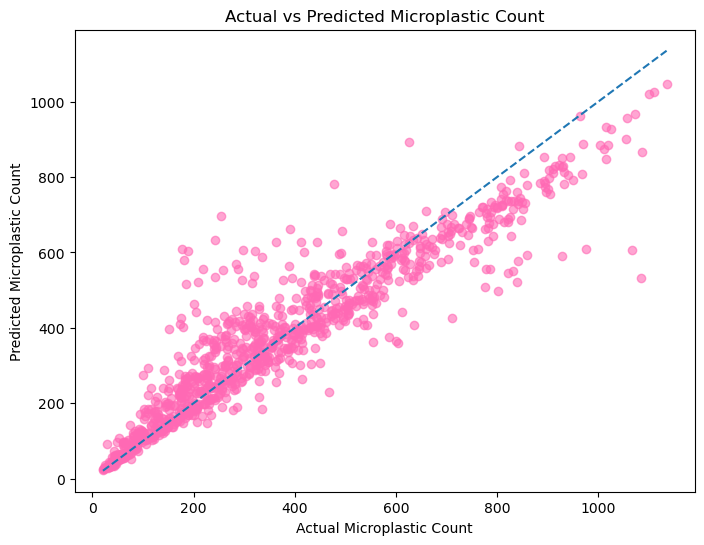

In [76]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(
    y_actual,
    y_predicted,
    alpha=0.6,color = 'hotpink'
)
min_value = min(
    y_actual.min(),
    y_predicted.min()
)
max_value = max(
    y_actual.max(),
    y_predicted.max()
)
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel(
    "Actual Microplastic Count"
)
plt.ylabel(
    "Predicted Microplastic Count"
)
plt.title(
    "Actual vs Predicted Microplastic Count"
)
plt.show()

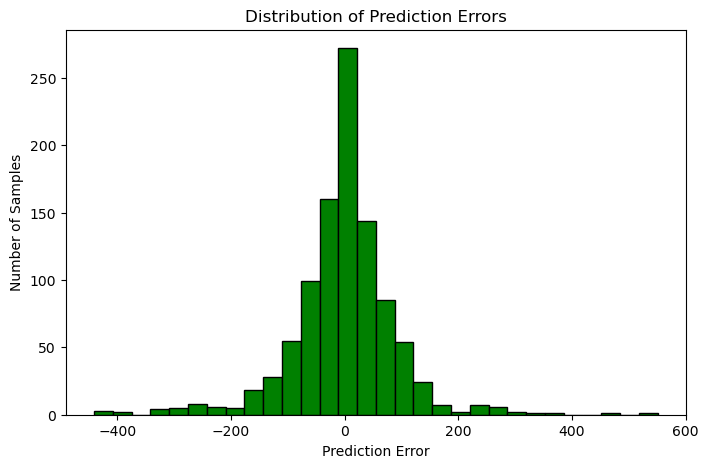

In [78]:
plt.figure(figsize=(8, 5))
plt.hist(
    predictions["Prediction_Error"],
    bins=30,color = 'green',edgecolor = 'black'
)
plt.xlabel(
    "Prediction Error"
)
plt.ylabel(
    "Number of Samples"
)
plt.title(
    "Distribution of Prediction Errors"
)
plt.show()

In [79]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [80]:
actual_risk = df[
    "Risk_Level"
]

In [81]:
predicted_risk = predictions[
    "Predicted_Risk_Level"
]

In [82]:
risk_accuracy = accuracy_score(
    actual_risk,
    predicted_risk
)

print(
    f"Risk Classification Accuracy: "
    f"{risk_accuracy * 100:.2f}%"
)

Risk Classification Accuracy: 79.90%


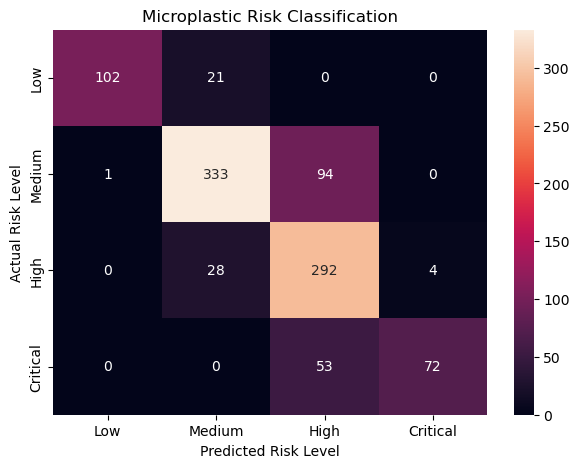

In [84]:
import seaborn as sns

labels = [
    "Low",
    "Medium",
    "High",
    "Critical"
]

cm = confusion_matrix(
    actual_risk,
    predicted_risk,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel(
    "Predicted Risk Level"
)

plt.ylabel(
    "Actual Risk Level"
)

plt.title(
    "Microplastic Risk Classification"
)

plt.show()